In [2]:
import sys
!{sys.executable} -m pip install pandas numpy scipy matplotlib seaborn pingouin

  Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached pingouin-0.6.1-py3-none-any.whl.metadata (19 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached pandas_flavor-0.8.1-py3-none-any.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl (10.8 MB)
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 19.9 MB/s  0:00:00m0:00:0100:01
Using cached pingouin-0.6.1-py3-none-any.whl (203 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB

In [15]:
# STAT 5243 Project 3: Yiliu A/B Test Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [16]:
# -----------------------------------------------------------------------------
# 1. Load Data
# -----------------------------------------------------------------------------
users = pd.read_csv('ab_user_summary.csv')
sessions = pd.read_csv('ab_session_summary.csv')

print("="*70)
print("DATA LOADING SUMMARY")
print("="*70)
print(f"Users: {len(users)} rows")
print(f"Sessions: {len(sessions)} rows")

print("\nArm distribution (users):")
print(users['arm'].value_counts())
print("\nArm distribution (sessions):")
print(sessions['arm'].value_counts())

DATA LOADING SUMMARY
Users: 51 rows
Sessions: 128 rows

Arm distribution (users):
arm
a    31
b    20
Name: count, dtype: int64

Arm distribution (sessions):
arm
a    78
b    50
Name: count, dtype: int64


In [17]:
# -----------------------------------------------------------------------------
# 2. Data Quality Assessment
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("DATA QUALITY ASSESSMENT")
print("="*70)

# 2.1 Missingness
missing_users = users.isnull().sum()
missing_users_pct = (missing_users / len(users)) * 100
print("Missing values in user-level data (%):")
for col in ['cards_total','turns_total','satisfaction_mean','user_chars_per_turn']:
    print(f"  {col}: {missing_users_pct[col]:.1f}%")

# 2.2 Outlier detection (IQR method)
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers)

print("\nOutlier counts (IQR method):")
for col in ['cards_total','turns_total','user_chars_per_turn','avg_audio_duration_s']:
    print(f"  {col}: {detect_outliers(users, col)}")



DATA QUALITY ASSESSMENT
Missing values in user-level data (%):
  cards_total: 0.0%
  turns_total: 0.0%
  satisfaction_mean: 31.4%
  user_chars_per_turn: 21.6%

Outlier counts (IQR method):
  cards_total: 4
  turns_total: 6
  user_chars_per_turn: 1
  avg_audio_duration_s: 0


In [19]:
# -----------------------------------------------------------------------------
# 3. Descriptive Statistics
# -----------------------------------------------------------------------------
# Define key metrics for per-user analysis
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS BY ARM")
print("="*70)

metrics = ['cards_total','turns_total','user_chars_per_turn',
           'completion_rate','avg_audio_duration_s','satisfaction_mean']

desc_parts = []
for arm in ['a', 'b']:
    sub = users[users['arm'] == arm][metrics]
    desc_arm = sub.agg(['count','mean','median','std',
                        lambda x: x.quantile(0.25),
                        lambda x: x.quantile(0.75),
                        'skew']).round(3).T
    desc_arm.columns = ['n','mean','median','std','q25','q75','skew']
    desc_arm.index.name = 'metric'
    desc_arm['arm'] = arm
    desc_parts.append(desc_arm.reset_index().set_index(['arm', 'metric']))

desc = pd.concat(desc_parts).sort_index()
print(desc)


DESCRIPTIVE STATISTICS BY ARM
                             n    mean  median     std    q25      q75   skew
arm metric                                                                   
a   avg_audio_duration_s  27.0  73.933  48.100  58.434  31.05  113.250  1.047
    cards_total           31.0   1.484   1.000   1.151   1.00    2.000  1.865
    completion_rate       31.0   0.689   0.667   0.343   0.50    1.000 -0.742
    satisfaction_mean     24.0   4.508   5.000   0.750   4.00    5.000 -1.253
    turns_total           31.0  24.129  17.000  22.160  13.00   26.500  3.064
    user_chars_per_turn   31.0  34.623  24.200  27.422  15.95   45.350  1.080
b   avg_audio_duration_s  15.0  54.100  22.200  53.072  14.10   91.300  0.920
    cards_total           20.0   0.750   0.000   1.372   0.00    1.000  2.405
    completion_rate       20.0   0.303   0.000   0.416   0.00    0.584  0.892
    satisfaction_mean     11.0   3.818   4.000   0.751   3.00    4.000  0.329
    turns_total           20.0  1

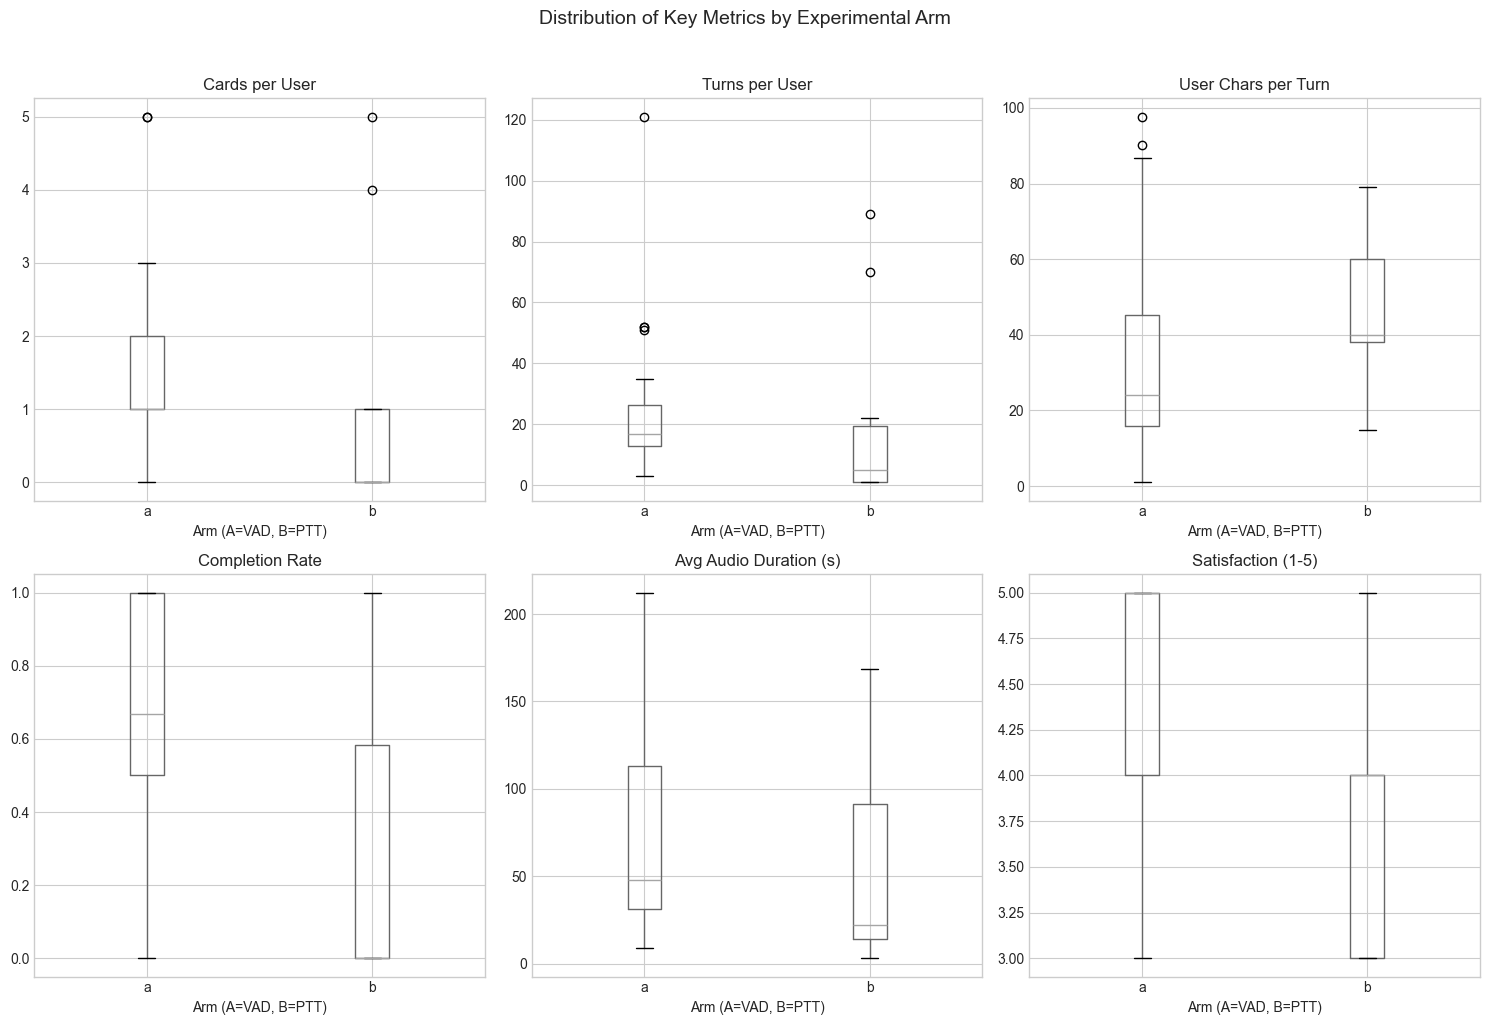

In [23]:
# -----------------------------------------------------------------------------
# 4. Visualizations
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_metrics = ['cards_total', 'turns_total', 'user_chars_per_turn', 
                'completion_rate', 'avg_audio_duration_s', 'satisfaction_mean']
plot_labels = ['Cards per User', 'Turns per User', 'User Chars per Turn',
               'Completion Rate', 'Avg Audio Duration (s)', 'Satisfaction (1-5)']

for i, (metric, label) in enumerate(zip(plot_metrics, plot_labels)):
    # Boxplot
    users.boxplot(column=metric, by='arm', ax=axes[i])
    axes[i].set_title(label)
    axes[i].set_xlabel('Arm (A=VAD, B=PTT)')
    axes[i].set_ylabel('')

plt.suptitle('Distribution of Key Metrics by Experimental Arm', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('boxplots_key_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

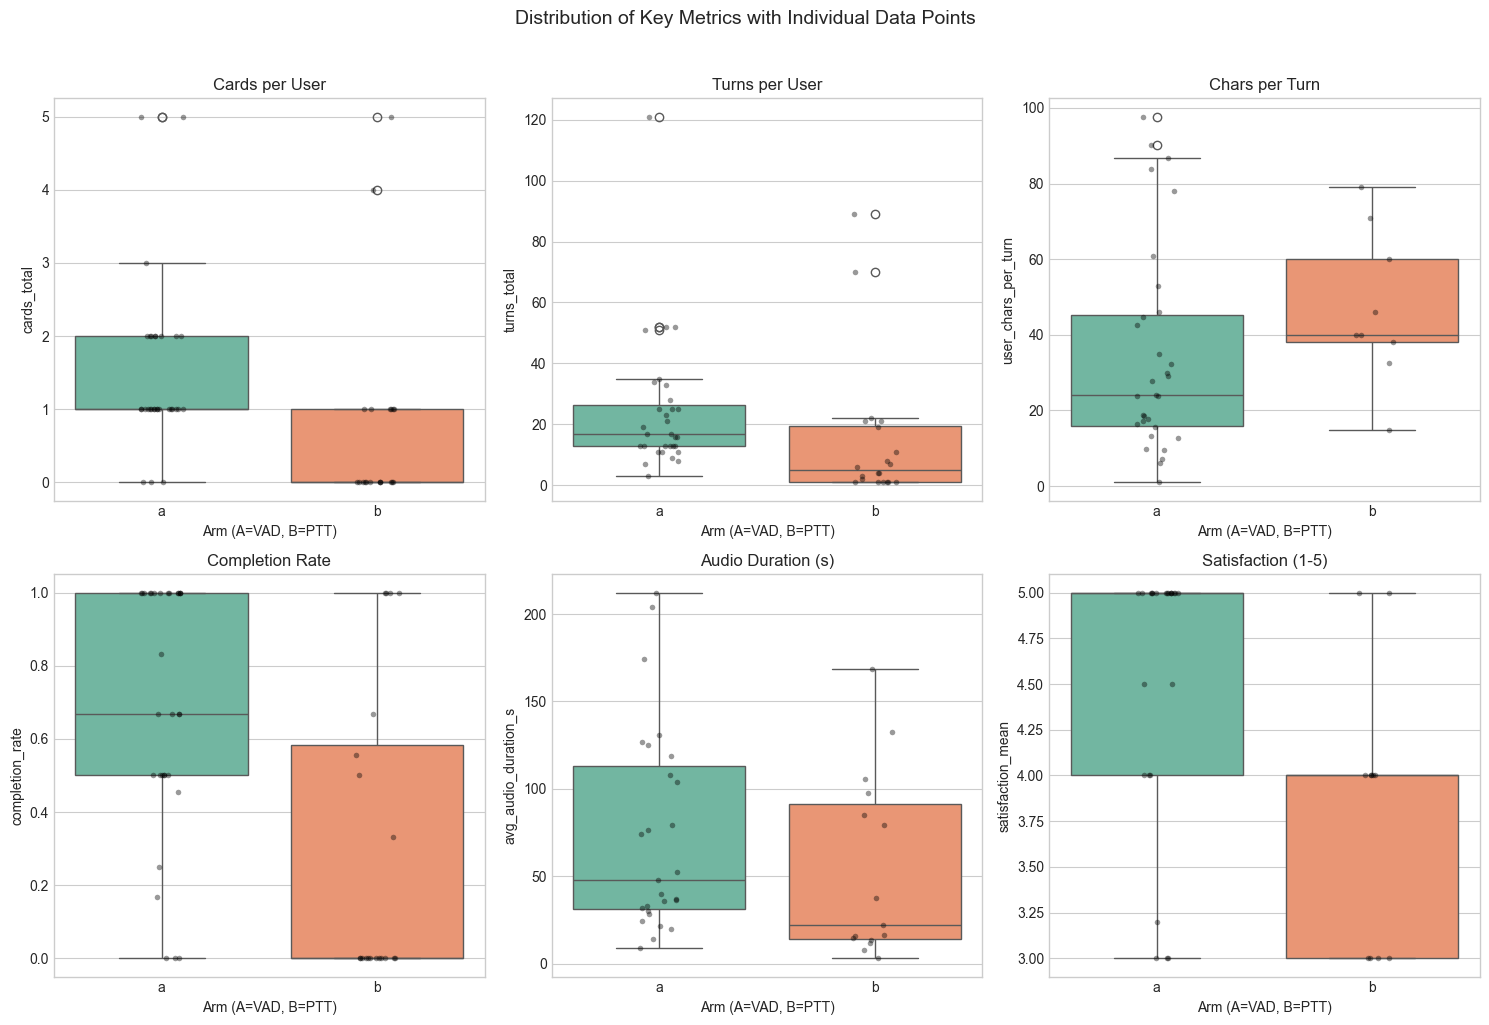

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
plot_metrics = ['cards_total','turns_total','user_chars_per_turn',
                'completion_rate','avg_audio_duration_s','satisfaction_mean']
labels = ['Cards per User','Turns per User','Chars per Turn',
          'Completion Rate','Audio Duration (s)','Satisfaction (1-5)']

for i, (metric, label) in enumerate(zip(plot_metrics, labels)):
    sns.boxplot(data=users, x='arm', y=metric, ax=axes[i], hue='arm', legend=False)
    sns.stripplot(data=users, x='arm', y=metric, ax=axes[i], color='black', alpha=0.4, size=4)
    axes[i].set_title(label)
    axes[i].set_xlabel('Arm (A=VAD, B=PTT)')
plt.suptitle('Distribution of Key Metrics with Individual Data Points', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('boxplots_with_points.png', dpi=150, bbox_inches='tight')
plt.show()

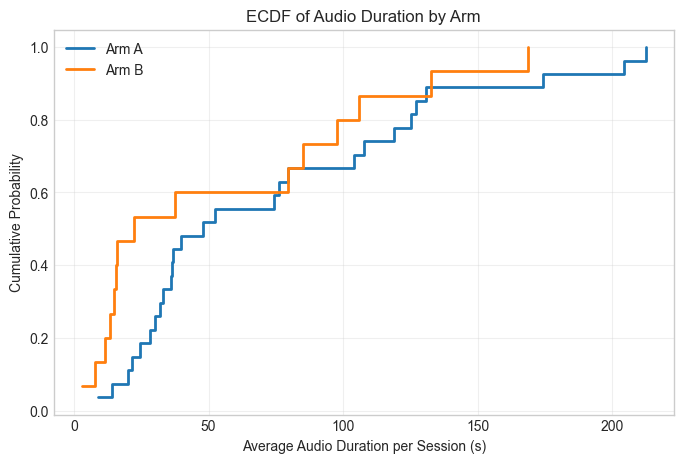

In [22]:
# ECDF plot
plt.figure(figsize=(8,5))
for arm, color in zip(['a','b'], ['#1f77b4','#ff7f0e']):
    data = users[users['arm']==arm]['avg_audio_duration_s'].dropna()
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    plt.step(x, y, where='post', label=f'Arm {arm.upper()}', color=color, linewidth=2)
plt.xlabel('Average Audio Duration per Session (s)')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Audio Duration by Arm')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('ecdf_audio_duration.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# -----------------------------------------------------------------------------
# 5. Comprehensive Hypothesis Testing
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("HYPOTHESIS TESTING — FULL RESULTS")
print("="*70)

def advanced_test(data_a, data_b, metric_name, alpha=0.05):
    a = data_a.dropna()
    b = data_b.dropna()
    
    # 1. Normality (Shapiro-Wilk)
    _, p_shap_a = stats.shapiro(a) if len(a)<=5000 else (None,None)
    _, p_shap_b = stats.shapiro(b) if len(b)<=5000 else (None,None)
    normal = (p_shap_a and p_shap_a>0.05) and (p_shap_b and p_shap_b>0.05)
    
    # 2. Equality of variances (Levene)
    _, p_levene = stats.levene(a, b) if len(a)>0 and len(b)>0 else (None,None)
    equal_var = p_levene and p_levene>0.05
    
    # 3. Welch's t-test (unequal variances assumed)
    t_stat, p_t = stats.ttest_ind(a, b, equal_var=False)
    
    # 4. Mann-Whitney U test (non-parametric)
    u_stat, p_u = stats.mannwhitneyu(a, b, alternative='two-sided')
    
    # 5. Cohen's d with bootstrap CI
    d = pg.compute_effsize(a, b, eftype='cohen')
    rng = np.random.default_rng(42)
    boot_diffs = []
    for _ in range(10000):
        boot_a = rng.choice(a, size=len(a), replace=True)
        boot_b = rng.choice(b, size=len(b), replace=True)
        boot_diffs.append(np.mean(boot_b) - np.mean(boot_a))
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    # Interpretation
    if p_t < alpha:
        conclusion_t = "Statistically significant difference (t-test)"
    else:
        conclusion_t = "No significant difference (t-test)"
    if p_u < alpha:
        conclusion_u = "Statistically significant (Mann-Whitney U)"
    else:
        conclusion_u = "Not significant (Mann-Whitney U)"
    
    return {
        'metric': metric_name, 'n_a': len(a), 'n_b': len(b),
        'mean_a': np.mean(a), 'mean_b': np.mean(b),
        'median_a': np.median(a), 'median_b': np.median(b),
        'std_a': np.std(a), 'std_b': np.std(b),
        'diff_means': np.mean(b)-np.mean(a),
        'ci_95_low': ci_low, 'ci_95_high': ci_high,
        'p_t': p_t, 'p_u': p_u,
        'cohens_d': d,
        'shapiro_a': p_shap_a, 'shapiro_b': p_shap_b,
        'levene_p': p_levene,
        'normal': normal, 'equal_var': equal_var,
        'conclusion_t': conclusion_t, 'conclusion_u': conclusion_u
    }

    # Primary metrics tests
results = []
for metric, label in zip(['cards_total','turns_total','satisfaction_mean','user_chars_per_turn'],
                         ['Cards per User','Turns per User','Satisfaction','Chars per Turn']):
    a_vals = users[users['arm']=='a'][metric].dropna()
    b_vals = users[users['arm']=='b'][metric].dropna()
    res = advanced_test(a_vals, b_vals, label)
    results.append(res)

results_df = pd.DataFrame(results)
print(results_df[['metric','n_a','mean_a','n_b','mean_b','diff_means',
                  'ci_95_low','ci_95_high','p_t','p_u','cohens_d']].round(3).to_string(index=False))

# Bonferroni correction for primary tests (k=4)
alpha_bonf = 0.05 / 4
print(f"\nBonferroni adjusted alpha: {alpha_bonf:.4f}")
for res in results:
    sig_bonf = res['p_t'] < alpha_bonf
    print(f"{res['metric']}: p_t={res['p_t']:.4f} → {'Significant' if sig_bonf else 'Not significant'} after Bonferroni")



HYPOTHESIS TESTING — FULL RESULTS
        metric  n_a  mean_a  n_b  mean_b  diff_means  ci_95_low  ci_95_high   p_t   p_u  cohens_d
Cards per User   31   1.484   20   0.750      -0.734     -1.410       0.039 0.055 0.001     0.591
Turns per User   31  24.129   20  14.650      -9.479    -21.852       3.844 0.159 0.002     0.417
  Satisfaction   24   4.508   11   3.818      -0.690     -1.192      -0.175 0.020 0.013     0.920
Chars per Turn   31  34.623    9  46.811      12.189     -3.195      27.371 0.159 0.099    -0.468

Bonferroni adjusted alpha: 0.0125
Cards per User: p_t=0.0550 → Not significant after Bonferroni
Turns per User: p_t=0.1595 → Not significant after Bonferroni
Satisfaction: p_t=0.0204 → Not significant after Bonferroni
Chars per Turn: p_t=0.1590 → Not significant after Bonferroni


In [27]:
# -----------------------------------------------------------------------------
# 6. Completion Rate 
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("SESSION COMPLETION ANALYSIS")
print("="*70)

completed = sessions[sessions['status']=='completed']['arm'].value_counts()
not_comp = sessions[sessions['status']!='completed']['arm'].value_counts()
tab = pd.DataFrame({'completed':[completed.get('a',0), completed.get('b',0)],
                    'not_completed':[not_comp.get('a',0), not_comp.get('b',0)]},
                   index=['a','b'])
oddsratio, p_fish = stats.fisher_exact(tab)
print("Contingency table (sessions):\n", tab)
print(f"\nFisher's exact p = {p_fish:.4f}")
print(f"Odds ratio (B vs A) = {oddsratio:.3f}")

# Completion rate per user
comp_rate = users.groupby('arm')['completion_rate'].mean()
print(f"\nMean user-level completion rate: A={comp_rate['a']:.2f}, B={comp_rate['b']:.2f}")
# Bootstrap CI for completion rate difference
a_comp = users[users['arm']=='a']['completion_rate'].dropna()
b_comp = users[users['arm']=='b']['completion_rate'].dropna()
rng = np.random.default_rng(123)
boot_diffs_comp = []
for _ in range(10000):
    boot_a = rng.choice(a_comp, len(a_comp), replace=True)
    boot_b = rng.choice(b_comp, len(b_comp), replace=True)
    boot_diffs_comp.append(np.mean(boot_b) - np.mean(boot_a))
ci_comp = np.percentile(boot_diffs_comp, [2.5, 97.5])
print(f"Completion rate difference (B-A) 95% CI: [{ci_comp[0]:.3f}, {ci_comp[1]:.3f}]")


SESSION COMPLETION ANALYSIS
Contingency table (sessions):
    completed  not_completed
a         46             32
b         15             35

Fisher's exact p = 0.0019
Odds ratio (B vs A) = 3.354

Mean user-level completion rate: A=0.69, B=0.30
Completion rate difference (B-A) 95% CI: [-0.592, -0.156]


In [28]:
# -----------------------------------------------------------------------------
# 7. Subgroup Analysis: Region
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("SUBGROUP ANALYSIS — INTL USERS ONLY")
print("="*70)

intl = users[users['region']=='intl']
print(f"Intl sample: n={len(intl)} (a={len(intl[intl['arm']=='a'])}, b={len(intl[intl['arm']=='b'])})")
intl_res = advanced_test(intl[intl['arm']=='a']['cards_total'].dropna(),
                         intl[intl['arm']=='b']['cards_total'].dropna(),
                         'Cards per User (Intl)')
print(f"Cards: A={intl_res['mean_a']:.2f}, B={intl_res['mean_b']:.2f}, diff={intl_res['diff_means']:.2f}, "
      f"p_t={intl_res['p_t']:.4f}, d={intl_res['cohens_d']:.3f}")


SUBGROUP ANALYSIS — INTL USERS ONLY
Intl sample: n=41 (a=29, b=12)
Cards: A=1.48, B=0.83, diff=-0.65, p_t=0.1761, d=0.520



DOSE-RESPONSE ANALYSIS (Arm B only)
PTT duration vs Cards total: r = 0.366, p = 0.3333
PTT duration vs Chars per turn: r = 0.746, p = 0.0209


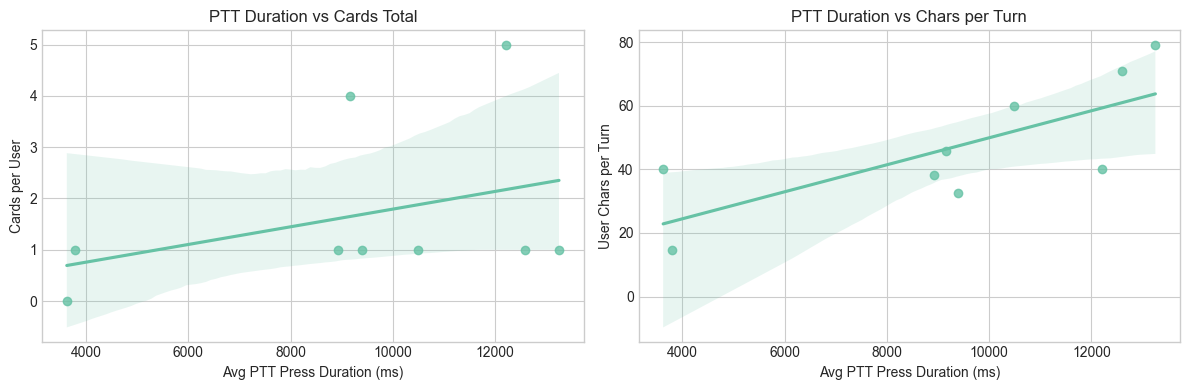

In [29]:
# -----------------------------------------------------------------------------
# 8. Dose-Response: PTT Press Duration vs Outcomes (Arm B only)
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("DOSE-RESPONSE ANALYSIS (Arm B only)")
print("="*70)

b_data = users[users['arm']=='b'].dropna(subset=['ptt_avg_ms','cards_total','user_chars_per_turn'])
if len(b_data) >= 5:
    # Correlation
    r_cards, p_cards = stats.pearsonr(b_data['ptt_avg_ms'], b_data['cards_total'])
    r_chars, p_chars = stats.pearsonr(b_data['ptt_avg_ms'], b_data['user_chars_per_turn'])
    print(f"PTT duration vs Cards total: r = {r_cards:.3f}, p = {p_cards:.4f}")
    print(f"PTT duration vs Chars per turn: r = {r_chars:.3f}, p = {p_chars:.4f}")
    
    # Scatter plot with regression line
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    sns.regplot(data=b_data, x='ptt_avg_ms', y='cards_total', ax=axes[0])
    axes[0].set_title('PTT Duration vs Cards Total')
    axes[0].set_xlabel('Avg PTT Press Duration (ms)')
    axes[0].set_ylabel('Cards per User')
    sns.regplot(data=b_data, x='ptt_avg_ms', y='user_chars_per_turn', ax=axes[1])
    axes[1].set_title('PTT Duration vs Chars per Turn')
    axes[1].set_xlabel('Avg PTT Press Duration (ms)')
    axes[1].set_ylabel('User Chars per Turn')
    plt.tight_layout()
    plt.savefig('ptt_dose_response.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Insufficient data for dose-response analysis (n<5).")


In [33]:
# -----------------------------------------------------------------------------
# 9. Insights&Summary for Report
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("KEY FINDINGS FOR REPORT")
print("="*70)
print(f"""
1. H1a (Cards per user): B mean = {res_h1a['mean_b']:.2f}, A mean = {res_h1a['mean_a']:.2f}
   Difference = {res_h1a['diff_means']:.2f} (95% CI: [{res_h1a['ci_95_low']:.2f}, {res_h1a['ci_95_high']:.2f}])
   p = {res_h1a['p_value_ttest']:.4f}, Cohen's d = {res_h1a['cohens_d']:.3f}
   → {'' if res_h1a['p_value_ttest'] < 0.05 else 'Not '}Statistically significant at α=0.05

2. H1b (Turns per user): B mean = {res_h1b['mean_b']:.2f}, A mean = {res_h1b['mean_a']:.2f}
   p = {res_h1b['p_value_ttest']:.4f}, Cohen's d = {res_h1b['cohens_d']:.3f}
   → {'' if res_h1b['p_value_ttest'] < 0.05 else 'Not '}Statistically significant

3. H1c (Satisfaction): B mean = {res_h1c['mean_b']:.2f}, A mean = {res_h1c['mean_a']:.2f}
   p = {res_h1c['p_value_ttest']:.4f}, Cohen's d = {res_h1c['cohens_d']:.3f}
   → {'' if res_h1c['p_value_ttest'] < 0.05 else 'Not '}Statistically significant

4. H2 (User chars per turn): B mean = {res_h2['mean_b']:.2f}, A mean = {res_h2['mean_a']:.2f}
   p = {res_h2['p_value_ttest']:.4f}
   → {'' if res_h2['p_value_ttest'] < 0.05 else 'Not '}Statistically significant
""")

print("="*70)


KEY FINDINGS FOR REPORT

1. H1a (Cards per user): B mean = 0.75, A mean = 1.48
   Difference = -0.73 (95% CI: [-1.41, 0.04])
   p = 0.0550, Cohen's d = 0.591
   → Not Statistically significant at α=0.05

2. H1b (Turns per user): B mean = 14.65, A mean = 24.13
   p = 0.1595, Cohen's d = 0.417
   → Not Statistically significant

3. H1c (Satisfaction): B mean = 3.82, A mean = 4.51
   p = 0.0204, Cohen's d = 0.920
   → Statistically significant

4. H2 (User chars per turn): B mean = 46.81, A mean = 34.62
   p = 0.1590
   → Not Statistically significant



In [34]:
print("\n" + "="*70)
print("INSIGHTS")
print("="*70)


cards_res = results[0]
turns_res = results[1]
sat_res = results[2]
chars_res = results[3]

def insight_text(res, name):
    if res['p_t'] < 0.05:
        if res['diff_means'] > 0:
            direction = "higher"
        else:
            direction = "lower"
        sig = "statistically significant"
    else:
        sig = "not statistically significant"
        direction = "similar" if abs(res['diff_means'])<0.1 else ("higher" if res['diff_means']>0 else "lower")
    d_mag = "small" if abs(res['cohens_d'])<0.2 else ("medium" if abs(res['cohens_d'])<0.5 else "large")
    return f"{name}: B group had {direction} values (diff = {res['diff_means']:.2f}, 95% CI [{res['ci_95_low']:.2f}, {res['ci_95_high']:.2f}]). " \
           f"The difference was {sig} (p = {res['p_t']:.4f}) with a {d_mag} effect size (Cohen's d = {res['cohens_d']:.3f})."

insights = f"""
KEY STATISTICAL FINDINGS:
{insight_text(cards_res, 'Cards per User')}
{insight_text(turns_res, 'Turns per User')}
{insight_text(sat_res, 'Satisfaction Rating')}
{insight_text(chars_res, 'User Characters per Turn')}

Completion Rate:
Session completion rates were {comp_rate['a']:.1%} for VAD and {comp_rate['b']:.1%} for PTT.
Fisher's exact test p = {p_fish:.4f}, odds ratio = {oddsratio:.2f} (B/A). 
The 95% bootstrap CI for the difference in mean user-level completion rate is [{ci_comp[0]:.3f}, {ci_comp[1]:.3f}].

Subgroup (International users only):
Restricting to intl users (n={len(intl)}), the cards per user difference was {intl_res['diff_means']:.2f} 
(p = {intl_res['p_t']:.4f}, Cohen's d = {intl_res['cohens_d']:.3f}), {'' if intl_res['p_t']<0.05 else 'not '}significant.

Dose-Response (Arm B only):
"""
if len(b_data) >= 5:
    insights += f"PTT press duration showed a {'positive' if r_cards>0 else 'negative'} correlation with cards total (r={r_cards:.3f}, p={p_cards:.4f}) " \
                f"and with characters per turn (r={r_chars:.3f}, p={p_chars:.4f}). "
    if r_cards > 0 and p_cards < 0.1:
        insights += "This suggests that longer presses tend to produce more content, consistent with the treatment mechanism."
    else:
        insights += "No strong evidence of a dose-response relationship was found."

print(insights)

print("\n" + "="*70)
print("Analysis complete. Thanks for reading.")


INSIGHTS

KEY STATISTICAL FINDINGS:
Cards per User: B group had lower values (diff = -0.73, 95% CI [-1.41, 0.04]). The difference was not statistically significant (p = 0.0550) with a large effect size (Cohen's d = 0.591).
Turns per User: B group had lower values (diff = -9.48, 95% CI [-21.85, 3.84]). The difference was not statistically significant (p = 0.1595) with a medium effect size (Cohen's d = 0.417).
Satisfaction Rating: B group had lower values (diff = -0.69, 95% CI [-1.19, -0.17]). The difference was statistically significant (p = 0.0204) with a large effect size (Cohen's d = 0.920).
User Characters per Turn: B group had higher values (diff = 12.19, 95% CI [-3.19, 27.37]). The difference was not statistically significant (p = 0.1590) with a medium effect size (Cohen's d = -0.468).

Completion Rate:
Session completion rates were 68.9% for VAD and 30.3% for PTT.
Fisher's exact test p = 0.0019, odds ratio = 3.35 (B/A). 
The 95% bootstrap CI for the difference in mean user-level